In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = '../data/'
EPA_FILE = DATA_DIR + 'EPA_SmartLocationDatabase_V3_Jan_2021_Final.csv'
PLACES_FILE = DATA_DIR + 'PLACES__Local_Data_for_Better_Health,_Census_Tract_Data,_2025_release_20260404.csv'

In [25]:
# EPA Smart Location Database (block group level)
# GEOID20 is stored as scientific notation in the CSV — read component FIPS columns as strings instead
epa = pd.read_csv(EPA_FILE, dtype={'STATEFP': str, 'COUNTYFP': str, 'TRACTCE': str})
print(f'EPA shape: {epa.shape}')
epa.head(2)

EPA shape: (220740, 117)


,OBJECTID,GEOID10,GEOID20,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,CBSA_Name,CBSA_POP,CBSA_EMP,CBSA_WRK,Ac_Total,Ac_Water,Ac_Land,Ac_Unpr,TotPop,CountHU,HH,P_WrkAge,AutoOwn0,Pct_AO0,AutoOwn1,...,D4A,D4B025,D4B050,D4C,D4D,D4E,D5AR,D5AE,D5BR,D5BE,D5CR,D5CRI,D5CE,D5CEI,D5DR,D5DRI,D5DE,D5DEI,D2A_Ranked,D2B_Ranked,D3B_Ranked,D4A_Ranked,NatWalkInd,Shape_Length,Shape_Area
0,1,481130000000.0000,481130000000.0000,48,113,7825,4,206.0000,"Dallas-Fort Worth, TX-OK",19100.0000,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,73.5950,0.0000,73.5950,73.5950,1202,460.0000,423.0000,0.5490,69,0.1631,39,...,362.1000,0.0000,0.0000,4.3300,37.6547,0.0036,433601,303660,135362,53504,0.0004,0.7859,0.0004,0.8413,0.0005,0.1847,0.0005,0.1377,6,14,15,17,14.0000,3110.3608,297836.0831
1,2,481130000000.0000,481130000000.0000,48,113,7825,2,206.0000,"Dallas-Fort Worth, TX-OK",19100.0000,"Dallas-Fort Worth-Arlington, TX",7189384,3545715,3364458,119.8299,0.0000,119.8299,119.2142,710,409.0000,409.0000,0.4660,0,0.0000,168,...,718.8400,0.0000,0.0095,4.3300,23.1261,0.0061,386504,272135,236885,90089,0.0004,0.7005,0.0003,0.7540,0.0009,0.3232,0.0008,0.2319,3,10,12,14,10.8333,3519.4691,484945.1466


In [26]:
# CDC PLACES 2025 (census tract level)
places = pd.read_csv(PLACES_FILE, dtype={'LocationID': str})
print(f'PLACES shape: {places.shape}')
places.head(2)

PLACES shape: (3047284, 24)


,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,Data_Value_Footnote_Symbol,Data_Value_Footnote,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,Geolocation,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text
0,2023,AL,Alabama,Jefferson,1073,1073010900,BRFSS,Disability,Any disability among adults,%,Crude prevalence,44.9000,NaN,NaN,40.7000,49.0000,"4,719","3,410",POINT (-86.7705771 33.5795996),01073010900,DISABLT,DISABILITY,CrdPrv,Any Disability
1,2023,AL,Alabama,Jefferson,1073,1073011207,BRFSS,Health Outcomes,Depression among adults,%,Crude prevalence,22.7000,NaN,NaN,19.9000,25.9000,"5,103","3,684",POINT (-86.6742325 33.6638358),01073011207,HLTHOUT,DEPRESSION,CrdPrv,Depression


In [27]:
print('EPA columns\n' + epa.dtypes.to_string())

EPA columns
OBJECTID          int64
GEOID10         float64
GEOID20         float64
STATEFP             str
COUNTYFP            str
TRACTCE             str
BLKGRPCE          int64
CSA             float64
CSA_Name            str
CBSA            float64
CBSA_Name           str
CBSA_POP          int64
CBSA_EMP          int64
CBSA_WRK          int64
Ac_Total        float64
Ac_Water        float64
Ac_Land         float64
Ac_Unpr         float64
TotPop            int64
CountHU         float64
HH              float64
P_WrkAge        float64
AutoOwn0          int64
Pct_AO0         float64
AutoOwn1          int64
Pct_AO1         float64
AutoOwn2p         int64
Pct_AO2p        float64
Workers           int64
R_LowWageWk       int64
R_MedWageWk       int64
R_HiWageWk        int64
R_PCTLOWWAGE    float64
TotEmp            int64
E5_Ret            int64
E5_Off            int64
E5_Ind            int64
E5_Svc            int64
E5_Ent            int64
E8_Ret            int64
E8_off            int64
E8_I

In [28]:
print('PLACES columns\n' + places.dtypes.to_string())

PLACES columns
Year                            int64
StateAbbr                         str
StateDesc                         str
CountyName                        str
CountyFIPS                      int64
LocationName                    int64
DataSource                        str
Category                          str
Measure                           str
Data_Value_Unit                   str
Data_Value_Type                   str
Data_Value                    float64
Data_Value_Footnote_Symbol    float64
Data_Value_Footnote           float64
Low_Confidence_Limit          float64
High_Confidence_Limit         float64
TotalPopulation                   str
TotalPop18plus                    str
Geolocation                       str
LocationID                        str
CategoryID                        str
MeasureId                         str
DataValueTypeID                   str
Short_Question_Text               str


In [29]:
# Unique measures in PLACES
print(places['MeasureId'].unique())

<ArrowStringArray>
[  'DISABILITY',   'DEPRESSION',    'ARTHRITIS',      'OBESITY',
       'STROKE',     'DIABETES',       'CANCER',      'CASTHMA',
      'HEARING',       'VISION',        'BINGE',     'MOBILITY',
        'GHLTH',       'BPHIGH',          'CHD',        'MHLTH',
     'LACKTRPT',     'HIGHCHOL',         'COPD',     'MAMMOUSE',
     'SELFCARE',    'INDEPLIVE',    'COGNITION',   'FOODINSECU',
   'CHOLSCREEN',      'CHECKUP',        'SLEEP',   'HOUSINSECU',
 'COLON_SCREEN',        'PHLTH',          'LPA',   'EMOTIONSPT',
       'DENTAL',      'ACCESS2',     'CSMOKING',    'FOODSTAMP',
   'LONELINESS',    'TEETHLOST',  'SHUTUTILITY',        'BPMED']
Length: 40, dtype: str


In [30]:
epa['GEOID_tract'] = epa['STATEFP'].str.zfill(2) + epa['COUNTYFP'].str.zfill(3) + epa['TRACTCE'].str.zfill(6)
epa_tract = epa.groupby('GEOID_tract').agg(walkability_mean=('NatWalkInd', 'mean'), walkability_min=('NatWalkInd', 'min'), walkability_max=('NatWalkInd', 'max')).reset_index()
print(epa_tract.shape)
epa_tract.head()

(74133, 4)


/var/folders/gj/qdh0ngnx7z9c285qtz68rshc0000gn/T/ipykernel_60530/3874634670.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  epa['GEOID_tract'] = epa['STATEFP'].str.zfill(2) + epa['COUNTYFP'].str.zfill(3) + epa['TRACTCE'].str.zfill(6)


,GEOID_tract,walkability_mean,walkability_min,walkability_max
0,01001020100,4.0833,2.6667,5.5000
1,01001020200,8.5833,7.6667,9.5000
2,01001020300,6.8333,4.6667,9.0000
3,01001020400,7.5417,6.0000,10.0000
4,01001020500,7.8889,6.1667,9.5000


In [31]:
# Missing values
print('EPA tract nulls:')
print(epa_tract.isnull().sum())

EPA tract nulls:
GEOID_tract         0
walkability_mean    0
walkability_min     0
walkability_max     0
dtype: int64


In [32]:
places_filtered = places[places['MeasureId'].isin(['OBESITY', 'DIABETES'])].copy()
places_filtered['MeasureId'].value_counts()

MeasureId
OBESITY     78815
DIABETES    78815
Name: count, dtype: int64

In [33]:
places_wide = places_filtered.pivot_table(index='LocationID', columns='MeasureId', values='Data_Value', aggfunc='first').reset_index()
places_wide.columns.name = None
places_wide = places_wide.rename(columns={'LocationID': 'GEOID_tract', 'OBESITY': 'obesity_pct', 'DIABETES': 'diabetes_pct'})
print(places_wide.shape)
places_wide.head()

(78815, 3)


,GEOID_tract,diabetes_pct,obesity_pct
0,01001020100,13.3000,39.4000
1,01001020200,15.8000,44.7000
2,01001020300,13.9000,40.3000
3,01001020400,12.8000,36.9000
4,01001020501,10.2000,34.7000


In [34]:
print(places_wide.isnull().sum())

GEOID_tract     0
diabetes_pct    0
obesity_pct     0
dtype: int64


In [35]:
df = epa_tract.merge(places_wide, on='GEOID_tract', how='inner')

print(f'Merged shape: {df.shape}')
print(f'\nNulls:\n{df.isnull().sum()}')
df = df.dropna()

df.head()

Merged shape: (56336, 6)

Nulls:
GEOID_tract         0
walkability_mean    0
walkability_min     0
walkability_max     0
diabetes_pct        0
obesity_pct         0
dtype: int64


,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000


In [36]:
df = df.dropna(subset=['obesity_pct', 'diabetes_pct'])
print(f'After dropping nulls: {df.shape}')

After dropping nulls: (56336, 6)


In [37]:
df[['walkability_mean', 'obesity_pct', 'diabetes_pct']].describe()

,walkability_mean,obesity_pct,diabetes_pct
count,56336.0000,56336.0000,56336.0000
mean,9.7862,34.2038,12.6433
std,4.0213,7.5487,4.0676
min,1.0000,11.6000,0.7000
25%,6.3333,28.9000,10.0000
50%,9.5000,34.3000,12.1000
75%,13.3333,39.2000,14.6000
max,19.8333,64.3000,50.8000


In [38]:
corr_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct']
print(df[corr_cols].corr().round(3))

                  walkability_mean  obesity_pct  diabetes_pct
walkability_mean            1.0000      -0.2780       -0.1230
obesity_pct                -0.2780       1.0000        0.7220
diabetes_pct               -0.1230       0.7220        1.0000


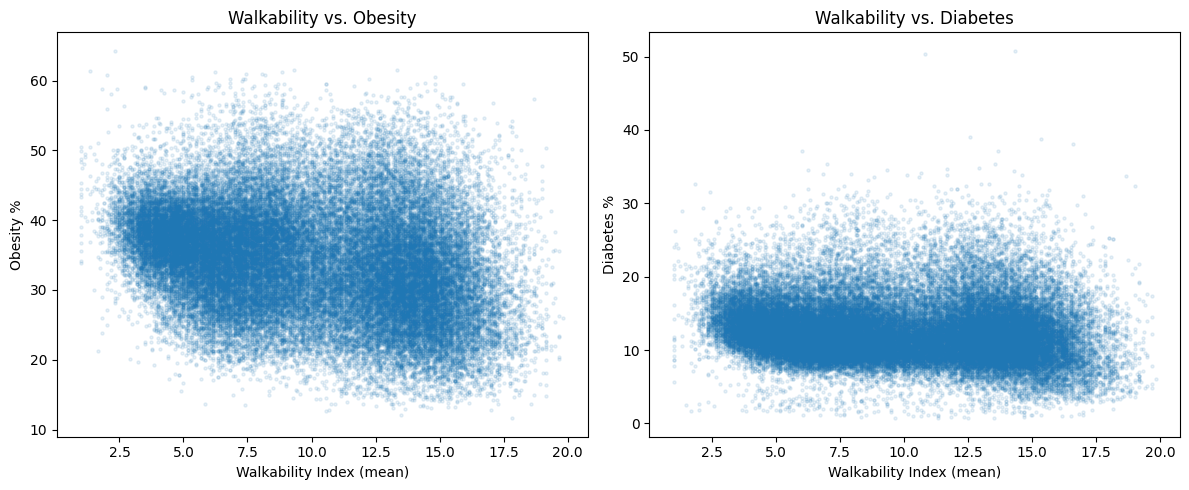

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['walkability_mean'], df['obesity_pct'], alpha=0.1, s=5)
axes[0].set(xlabel='Walkability Index (mean)', ylabel='Obesity %', title='Walkability vs. Obesity')
axes[1].scatter(df['walkability_mean'], df['diabetes_pct'], alpha=0.1, s=5)
axes[1].set(xlabel='Walkability Index (mean)', ylabel='Diabetes %', title='Walkability vs. Diabetes')
plt.tight_layout()
plt.show()

In [40]:
FOOD_FILE = pd.read_csv(DATA_DIR + 'food_access.csv')

In [41]:
food = FOOD_FILE
print(f'FOOD shape: {food.shape}')
food.head(2)

FOOD shape: (72531, 147)


,CensusTract,State,County,Urban,Pop2010,OHU2010,GroupQuartersFlag,NUMGQTRS,PCTGQTRS,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_1And20,LILATracts_Vehicle,HUNVFlag,LowIncomeTracts,PovertyRate,MedianFamilyIncome,LA1and10,LAhalfand10,LA1and20,LATracts_half,LATracts1,LATracts10,LATracts20,LATractsVehicle_20,...,laasian20share,lanhopi20,lanhopi20share,laaian20,laaian20share,laomultir20,laomultir20share,lahisp20,lahisp20share,lahunv20,lahunv20share,lasnap20,lasnap20share,TractLOWI,TractKids,TractSeniors,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,TractHUNV,TractSNAP
0,1001020100,Alabama,Autauga County,1,1912,693,0,0.0000,0.0000,0,0,0,0,0,0,11.3365,81250.0000,1,1,1,1,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,455.0000,507.0000,221.0000,1622.0000,217.0000,14.0000,0.0000,14.0000,45.0000,44.0000,6.0000,102.0000
1,1001020200,Alabama,Autauga County,1,2170,743,0,181.0000,8.3410,1,1,1,0,0,1,17.8768,49000.0000,1,1,1,1,1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,802.0000,606.0000,214.0000,888.0000,1217.0000,5.0000,0.0000,5.0000,55.0000,75.0000,89.0000,156.0000


In [42]:
print(food.isnull().sum()[food.isnull().sum() > 1000])

LAPOP1_10        29957
LAPOP05_10       14540
LAPOP1_20        35914
LALOWI1_10       29957
LALOWI05_10      14540
                 ...  
lahisp20share    71025
lahunv20         71025
lahunv20share    70920
lasnap20         71025
lasnap20share    70920
Length: 110, dtype: int64


In [43]:
food_vars = ['CensusTract', 'LILATracts_1And10', 'LILATracts_halfAnd10', 'LILATracts_Vehicle', 'LowIncomeTracts', 'lapop1share', 'lalowi1share', 'lahunv1', 'lahunv1share', 'PovertyRate', 'MedianFamilyIncome', 'Urban']

food_slim = food[food_vars].copy()
food_slim['CensusTract'] = food_slim['CensusTract'].astype(str).str.zfill(11)

print(f'food_slim shape: {food_slim.shape}')
print(f'Nulls:\n{food_slim.isnull().sum()}')
food_slim.head()

food_slim shape: (72531, 12)
Nulls:
CensusTract                 0
LILATracts_1And10           0
LILATracts_halfAnd10        0
LILATracts_Vehicle          0
LowIncomeTracts             0
lapop1share             19989
lalowi1share            19989
lahunv1                 19989
lahunv1share            19966
PovertyRate                 3
MedianFamilyIncome        748
Urban                       0
dtype: int64


,CensusTract,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban
0,01001020100,0,0,0,0,99.1890,24.1108,5.4904,0.7923,11.3365,81250.0000,1
1,01001020200,1,1,0,1,58.1102,27.8292,66.9035,9.0045,17.8768,49000.0000,1
2,01001020300,0,0,0,0,46.0037,14.1791,0.0000,0.0000,15.0460,62609.0000,1
3,01001020400,0,0,0,0,31.0868,7.8253,7.9414,0.4612,2.8452,70607.0000,1
4,01001020500,0,0,0,0,24.5504,5.4469,55.2119,1.3526,15.1509,96334.0000,1


In [44]:
import os
from dotenv import load_dotenv
from census import Census

load_dotenv('../.env')
c = Census(os.environ.get('CENSUS-KEY'))

In [45]:
import pandas as pd

variables = ('NAME', 'B19013_001E', 'B08201_002E', 'B03002_003E', 'B03002_004E', 'B03002_012E', 'B01003_001E', 'B11001_001E')
results = []

for state_fips in c.acs5.get('NAME', {'for': 'state:*'}):
    fips = state_fips['state']
    data = c.acs5.state_county_tract(variables, fips, '*', '*')
    results.extend(data)

CENSUS = pd.DataFrame(results)

KeyboardInterrupt: 

In [46]:
CENSUS = CENSUS.rename(columns={'B19013_001E': 'MHI', 'B08201_002E': 'NO_VEHICLE_HOUSEHOLDS', 'B03002_003E': 'NON-HISPANIC WHITE POPULATION', 'B03002_004E': 'BLACK POPULATION', 'B03002_012E': 'HISPANIC POPULATION', 'B01003_001E': 'TOTAL POPULATION', 'B11001_001E': 'TOTAL HOUSEHOLDS'})
CENSUS.head()

NameError: name 'CENSUS' is not defined

In [ ]:
DEMOGRAPHICS = CENSUS.iloc[:, [3,4,5]].apply(lambda x: x / CENSUS[CENSUS.columns[6]])

In [ ]:
DEMOGRAPHICS = DEMOGRAPHICS.rename(columns={'NON-HISPANIC WHITE POPULATION': 'NHW PERCENT', 'BLACK POPULATION': 'BLACK PERCENT', 'HISPANIC POPULATION': 'HISPANIC PERCENT'})
DEMOGRAPHICS['NO_VEHICLE_RATIO'] = CENSUS['NO_VEHICLE_HOUSEHOLDS'] / CENSUS['TOTAL HOUSEHOLDS']
DEMOGRAPHICS['TRACT'] = CENSUS['state'] + CENSUS['county'] + CENSUS['tract']
DEMOGRAPHICS['MHI'] = CENSUS['MHI']
DEMOGRAPHICS.head()

,NHW PERCENT,BLACK PERCENT,HISPANIC PERCENT,NO_VEHICLE_RATIO,TRACT,MHI
0,0.7076,0.0897,0.1065,0.0536,01001020100,62407.0000
1,0.4175,0.4541,0.0114,0.0647,01001020200,59028.0000
2,0.6623,0.2703,0.0108,0.0830,01001020300,66698.0000
3,0.8692,0.0616,0.0199,0.0619,01001020400,75956.0000
4,0.7876,0.1083,0.0489,0.0000,01001020501,81936.0000


In [ ]:
df.head()

,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000


In [ ]:
df = df.merge(DEMOGRAPHICS, left_on='GEOID_tract', right_on='TRACT', how='left').drop(columns='TRACT')

print(f'Shape after demographics merge: {df.shape}')
print(f'\nNulls:\n{df.isnull().sum()}')
df.head()

Shape after demographics merge: (56336, 11)

Nulls:
GEOID_tract           0
walkability_mean      0
walkability_min       0
walkability_max       0
diabetes_pct          0
obesity_pct           0
NHW PERCENT          19
BLACK PERCENT        19
HISPANIC PERCENT     19
NO_VEHICLE_RATIO    145
MHI                  12
dtype: int64


,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,NHW PERCENT,BLACK PERCENT,HISPANIC PERCENT,NO_VEHICLE_RATIO,MHI
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000,0.7076,0.0897,0.1065,0.0536,62407.0000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000,0.4175,0.4541,0.0114,0.0647,59028.0000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000,0.6623,0.2703,0.0108,0.0830,66698.0000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000,0.8692,0.0616,0.0199,0.0619,75956.0000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000,0.6815,0.2034,0.0645,0.0228,75375.0000


In [ ]:
key_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'NHW PERCENT', 'BLACK PERCENT', 'HISPANIC PERCENT', 'NO_VEHICLE_RATIO']
print(df[key_cols].isnull().sum())

walkability_mean      0
obesity_pct           0
diabetes_pct          0
MHI                  12
NHW PERCENT          19
BLACK PERCENT        19
HISPANIC PERCENT     19
NO_VEHICLE_RATIO    145
dtype: int64


In [ ]:
before = len(df)
df = df.dropna(subset=key_cols)
print(f'Dropped {before - len(df)} rows, final shape: {df.shape}')

Dropped 145 rows, final shape: (56191, 11)


In [ ]:
df = df.rename(columns={'NHW PERCENT': 'nhw_pct', 'BLACK PERCENT': 'black_pct', 'HISPANIC PERCENT': 'hispanic_pct', 'NO_VEHICLE_RATIO': 'no_vehicle_ratio'})

In [ ]:
before = len(df)
df = df[df['MHI'] >= 0]
print(f'Removed {before - len(df)} rows with negative MHI')

Removed 216 rows with negative MHI


In [ ]:
before = len(df)
df = df.drop_duplicates(subset='GEOID_tract')
print(f'Removed {before - len(df)} duplicates, final shape: {df.shape}')

Removed 0 duplicates, final shape: (55975, 11)


In [ ]:
key_cols_new = ['walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'no_vehicle_ratio']
df[key_cols_new].describe().round(2)

,walkability_mean,obesity_pct,diabetes_pct,MHI,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio
count,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000
mean,9.7900,34.1900,12.6500,83360.0000,0.5800,0.1300,0.1800,0.0900
std,4.0200,7.5200,4.0200,40962.2700,0.3000,0.2100,0.2200,0.1200
min,1.0000,11.6000,0.9000,2499.0000,0.0000,0.0000,0.0000,0.0000
25%,6.3300,28.8000,10.0000,55500.0000,0.3400,0.0100,0.0400,0.0200
50%,9.5000,34.3000,12.1000,74077.0000,0.6500,0.0400,0.1000,0.0500
75%,13.3300,39.2000,14.6000,101085.0000,0.8300,0.1500,0.2400,0.1100
max,19.8300,61.6000,50.8000,250001.0000,1.0000,1.0000,1.0000,0.9700


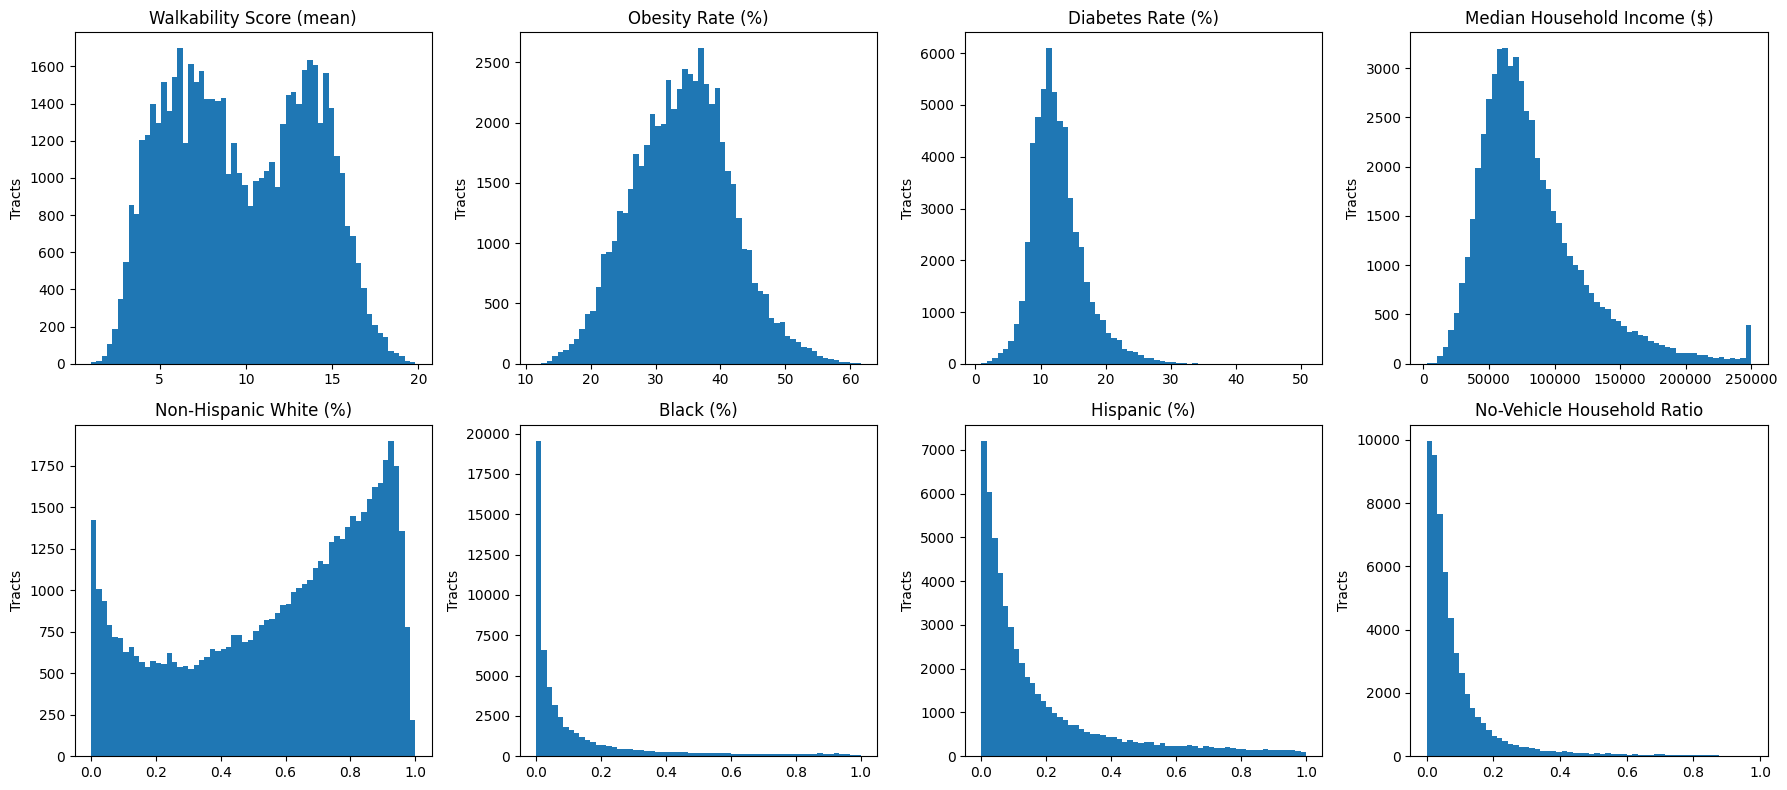

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
plot_vars = [('walkability_mean', 'Walkability Score (mean)'), ('obesity_pct', 'Obesity Rate (%)'), ('diabetes_pct', 'Diabetes Rate (%)'), ('MHI', 'Median Household Income ($)'), ('nhw_pct', 'Non-Hispanic White (%)'), ('black_pct', 'Black (%)'), ('hispanic_pct', 'Hispanic (%)'), ('no_vehicle_ratio', 'No-Vehicle Household Ratio')]
for ax, (col, label) in zip(axes.flat, plot_vars):
    ax.hist(df[col].dropna(), bins=60)
    ax.set(title=label, ylabel='Tracts')
plt.tight_layout()
plt.savefig('../data/distributions.png')
plt.show()

### 8c. Correlation Heatmap

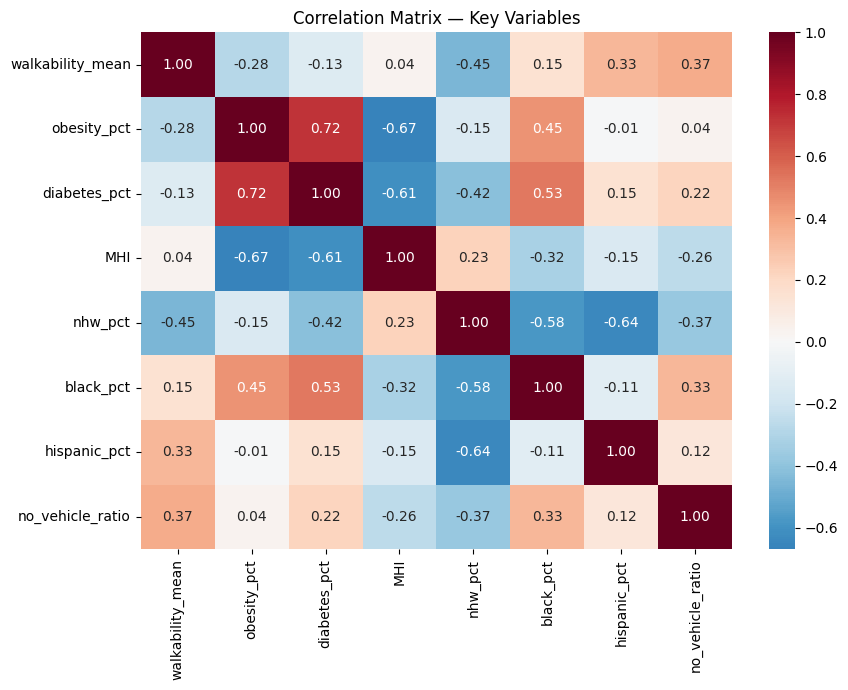

In [ ]:
corr_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'no_vehicle_ratio']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Variables')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()

### 8d. Key Bivariate Relationships

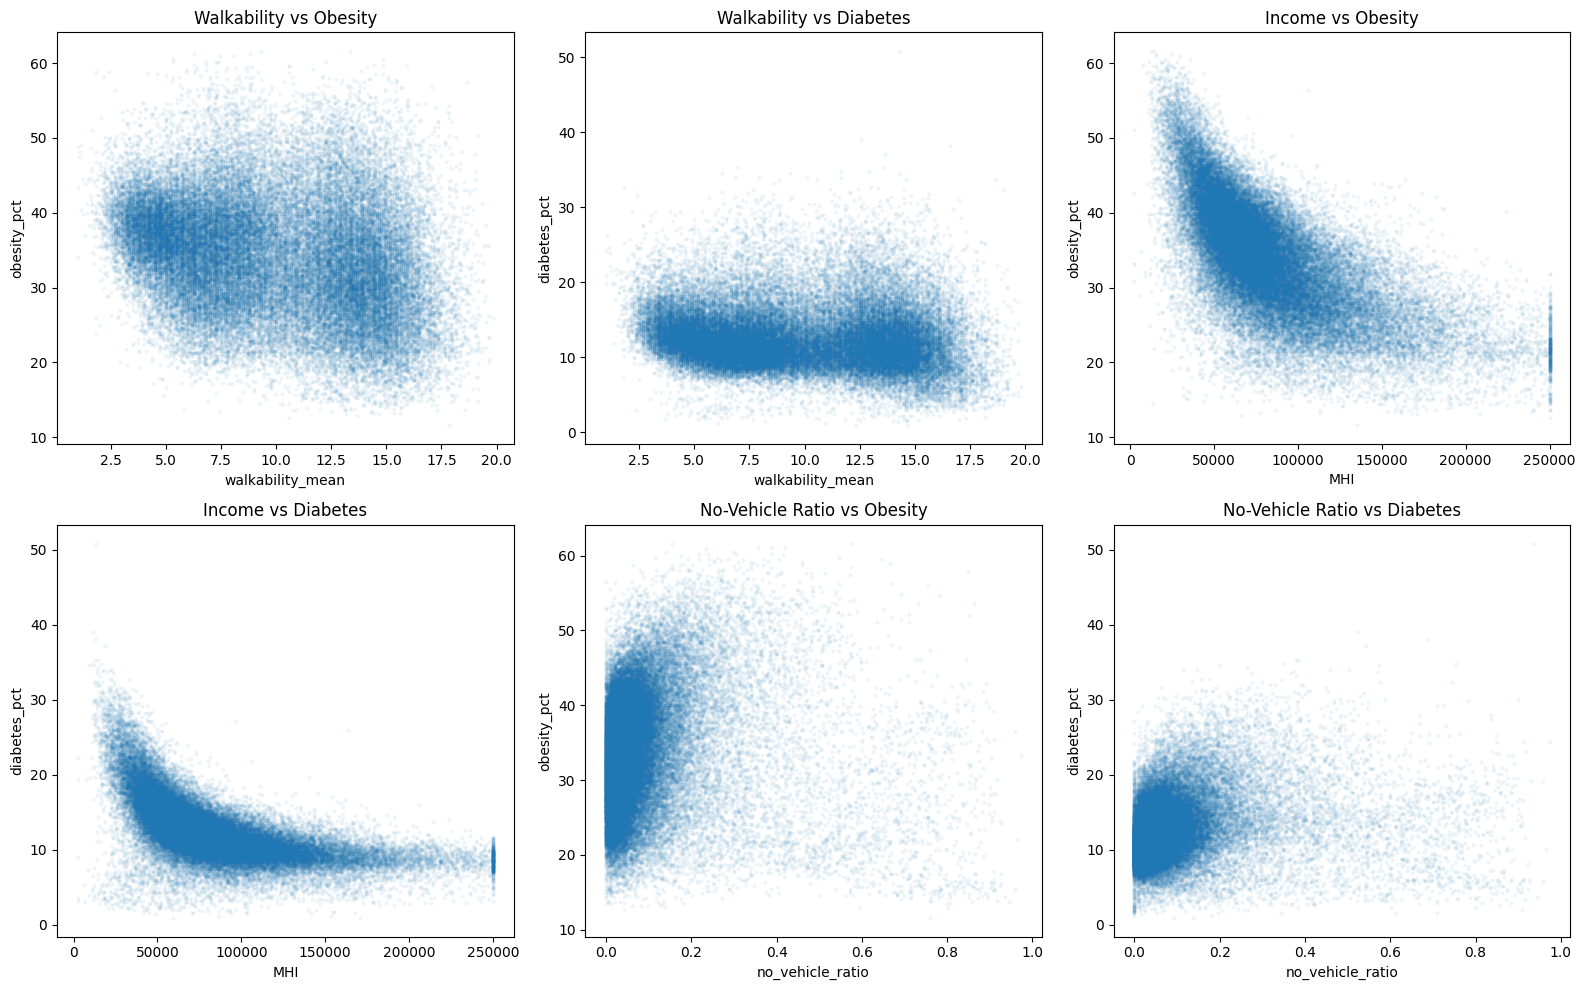

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

pairs = [('walkability_mean', 'obesity_pct','Walkability vs Obesity'),('walkability_mean', 'diabetes_pct','Walkability vs Diabetes'),('MHI','obesity_pct','Income vs Obesity'),('MHI','diabetes_pct','Income vs Diabetes'),('no_vehicle_ratio', 'obesity_pct','No-Vehicle Ratio vs Obesity'),('no_vehicle_ratio', 'diabetes_pct','No-Vehicle Ratio vs Diabetes'),]

for ax, (x, y, title) in zip(axes.flat, pairs):
    ax.scatter(df[x], df[y], alpha=0.05, s=4)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('../data/bivariate_scatter.png')
plt.show()

### 8e. State-Level Variation

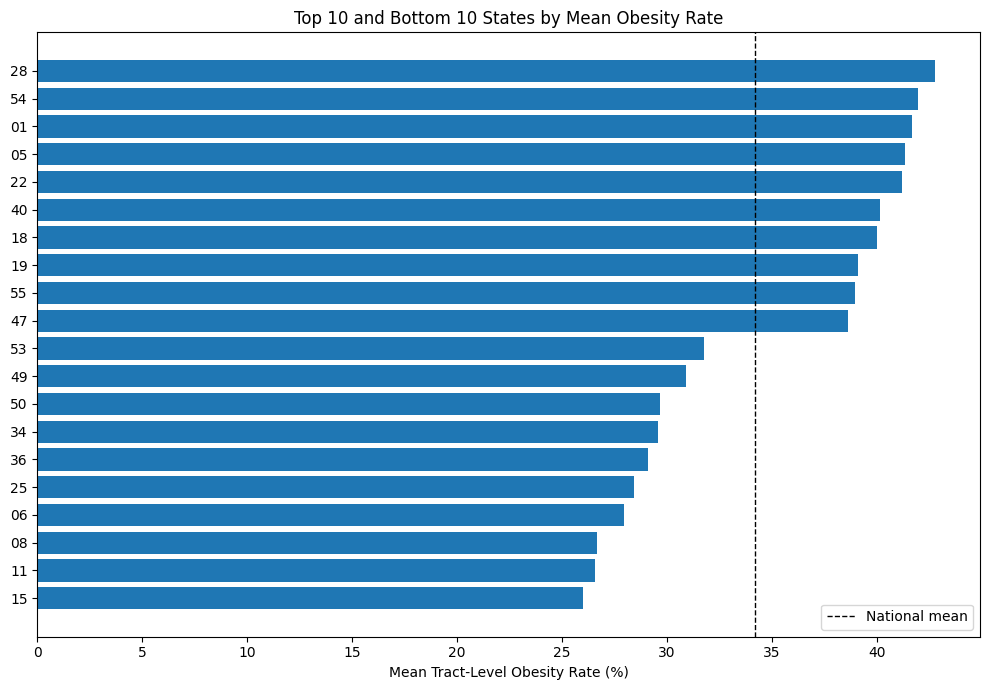

In [ ]:
df['state_fips'] = df['GEOID_tract'].str[:2]
state_obesity = df.groupby('state_fips')['obesity_pct'].agg(['mean', 'std', 'count']).rename(columns={'mean': 'mean_obesity', 'std': 'std_obesity', 'count': 'n_tracts'}).sort_values('mean_obesity')
both = pd.concat([state_obesity.head(10), state_obesity.tail(10)])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(both.index, both['mean_obesity'])
ax.axvline(df['obesity_pct'].mean(), color='black', linestyle='--', linewidth=1, label='National mean')
ax.set(xlabel='Mean Tract-Level Obesity Rate (%)', title='Top 10 and Bottom 10 States by Mean Obesity Rate')
ax.legend()
plt.tight_layout()
plt.savefig('../data/state_obesity.png')
plt.show()

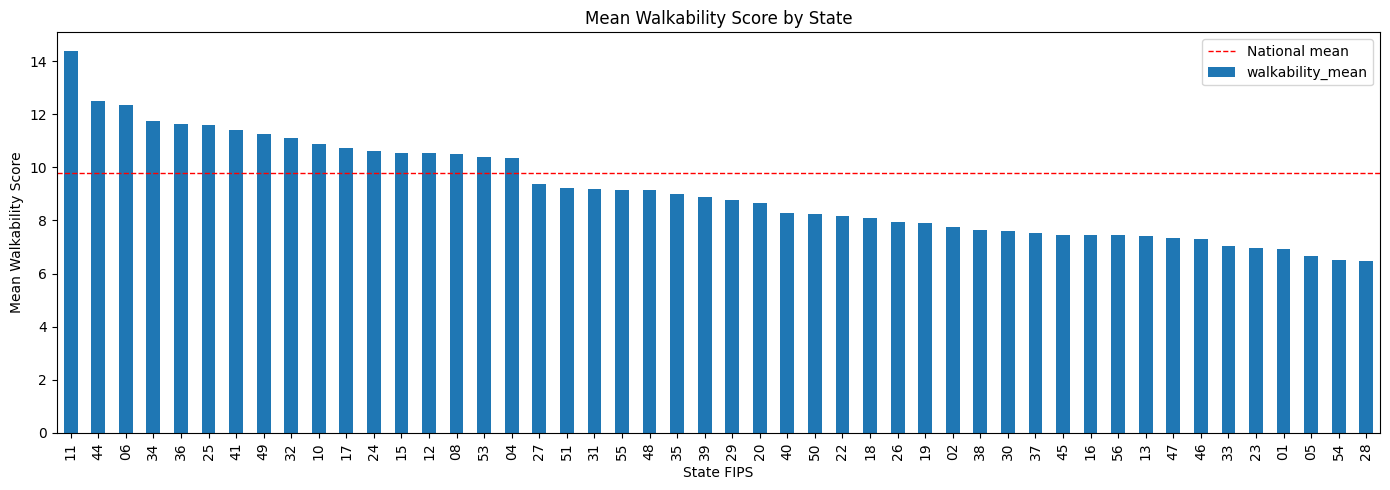

In [ ]:
state_walk = df.groupby('state_fips')['walkability_mean'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
state_walk.plot(kind='bar', ax=ax)
ax.axhline(df['walkability_mean'].mean(), color='red', linestyle='--', linewidth=1, label='National mean')
ax.set(xlabel='State FIPS', ylabel='Mean Walkability Score', title='Mean Walkability Score by State')
ax.legend()
plt.tight_layout()
plt.savefig('../data/state_walkability.png')
plt.show()

In [ ]:
df = df.merge(food_slim, left_on='GEOID_tract', right_on='CensusTract', how='left').drop(columns='CensusTract')
print(df.shape)
print(df.isnull().sum())
df.head()

(55975, 23)
GEOID_tract                 0
walkability_mean            0
walkability_min             0
walkability_max             0
diabetes_pct                0
obesity_pct                 0
nhw_pct                     0
black_pct                   0
hispanic_pct                0
no_vehicle_ratio            0
MHI                         0
state_fips                  0
LILATracts_1And10           1
LILATracts_halfAnd10        1
LILATracts_Vehicle          1
LowIncomeTracts             1
lapop1share             16730
lalowi1share            16730
lahunv1                 16730
lahunv1share            16729
PovertyRate                 1
MedianFamilyIncome        196
Urban                       1
dtype: int64


,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio,MHI,state_fips,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000,0.7076,0.0897,0.1065,0.0536,62407.0000,01,0.0000,0.0000,0.0000,0.0000,99.1890,24.1108,5.4904,0.7923,11.3365,81250.0000,1.0000
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000,0.4175,0.4541,0.0114,0.0647,59028.0000,01,1.0000,1.0000,0.0000,1.0000,58.1102,27.8292,66.9035,9.0045,17.8768,49000.0000,1.0000
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000,0.6623,0.2703,0.0108,0.0830,66698.0000,01,0.0000,0.0000,0.0000,0.0000,46.0037,14.1791,0.0000,0.0000,15.0460,62609.0000,1.0000
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000,0.8692,0.0616,0.0199,0.0619,75956.0000,01,0.0000,0.0000,0.0000,0.0000,31.0868,7.8253,7.9414,0.4612,2.8452,70607.0000,1.0000
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000,0.6815,0.2034,0.0645,0.0228,75375.0000,01,1.0000,1.0000,0.0000,1.0000,93.7177,43.2053,71.7098,5.4699,21.5777,69521.0000,1.0000


In [ ]:
df.describe()

,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio,MHI,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban
count,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55975.0000,55974.0000,55974.0000,55974.0000,55974.0000,39245.0000,39245.0000,39245.0000,39246.0000,55974.0000,55779.0000,55974.0000
mean,9.7908,8.2224,11.3874,12.6461,34.1874,0.5778,0.1339,0.1834,0.0912,83359.9968,0.1281,0.2886,0.1324,0.4295,53.1543,16.1130,36.1475,2.6441,15.2904,76908.8578,0.7714
std,4.0155,4.0721,4.2870,4.0224,7.5230,0.2953,0.2126,0.2180,0.1233,40962.2670,0.3342,0.4531,0.3389,0.4950,37.3003,15.5142,51.8601,4.0485,11.6707,38203.0722,0.4199
min,1.0000,1.0000,1.0000,0.9000,11.6000,0.0000,0.0000,0.0000,0.0000,2499.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2499.0000,0.0000
25%,6.3333,4.8333,7.6667,10.0000,28.8000,0.3437,0.0081,0.0357,0.0227,55500.0000,0.0000,0.0000,0.0000,0.0000,16.0203,3.1433,4.2691,0.3057,6.6078,50968.5000,1.0000
50%,9.5000,7.5000,11.6667,12.1000,34.3000,0.6473,0.0397,0.0955,0.0508,74077.0000,0.0000,0.0000,0.0000,0.0000,52.6968,11.5208,19.2753,1.3785,12.1833,68287.0000,1.0000
75%,13.3333,11.6667,15.1667,14.6000,39.2000,0.8344,0.1501,0.2401,0.1053,101085.0000,0.0000,1.0000,0.0000,1.0000,94.8432,25.4518,48.4475,3.4312,20.8315,93523.0000,1.0000
max,19.8333,19.8333,20.0000,50.8000,61.6000,1.0000,1.0000,1.0000,0.9736,250001.0000,1.0000,1.0000,1.0000,1.0000,100.0000,100.0000,1794.2612,78.4891,99.5086,250001.0000,1.0000


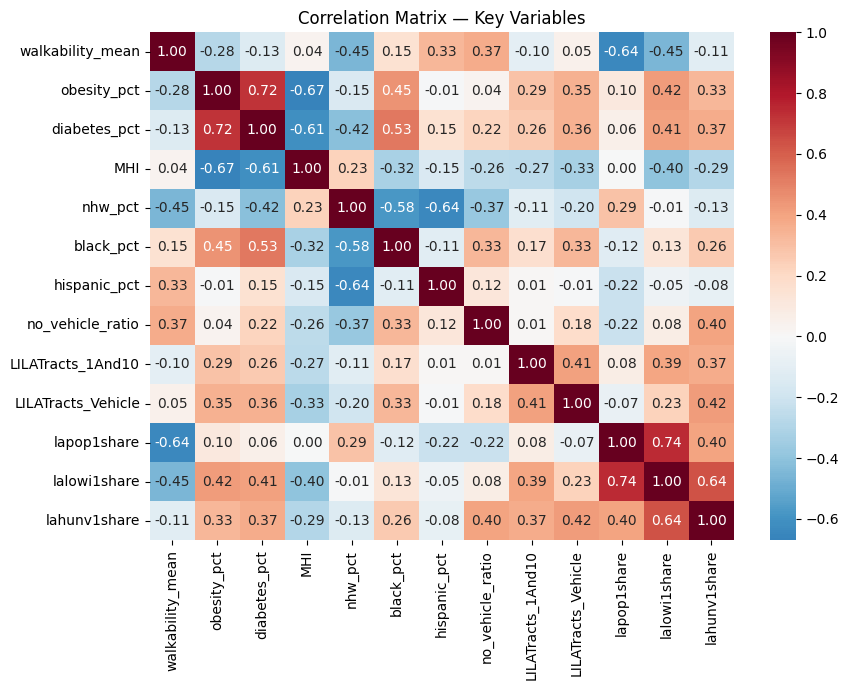

In [ ]:
corr_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'no_vehicle_ratio', 'LILATracts_1And10', 'LILATracts_Vehicle', 'lapop1share', 'lalowi1share', 'lahunv1share']

corr = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Matrix — Key Variables')
plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png')
plt.show()

### 8f. Regional Patterns & Outlier Tracts

In [ ]:
# Map 2-digit state FIPS → Census region
region_map = {'09': 'Northeast', '23': 'Northeast', '25': 'Northeast', '33': 'Northeast',
    '44': 'Northeast', '50': 'Northeast', '34': 'Northeast', '36': 'Northeast',
    '42': 'Northeast', '17': 'Midwest', '18': 'Midwest', '26': 'Midwest', '39': 'Midwest',
    '55': 'Midwest', '19': 'Midwest', '20': 'Midwest', '27': 'Midwest',
    '29': 'Midwest','31': 'Midwest', '38': 'Midwest', '46': 'Midwest',
    '10': 'South', '11': 'South', '12': 'South', '13': 'South',
    '24': 'South', '37': 'South', '45': 'South', '51': 'South',
    '54': 'South', '01': 'South', '21': 'South', '28': 'South',
    '47': 'South', '05': 'South', '22': 'South', '40': 'South',
    '48': 'South', '04': 'West', '08': 'West', '16': 'West', '30': 'West',
    '32': 'West', '35': 'West', '49': 'West', '56': 'West',
    '02': 'West', '06': 'West', '15': 'West', '41': 'West', '53': 'West'}

df['region'] = df['state_fips'].map(region_map).fillna('Other')
print(df['region'].value_counts())


region
South        19282
Midwest      15137
West         13241
Northeast     8315
Name: count, dtype: int64


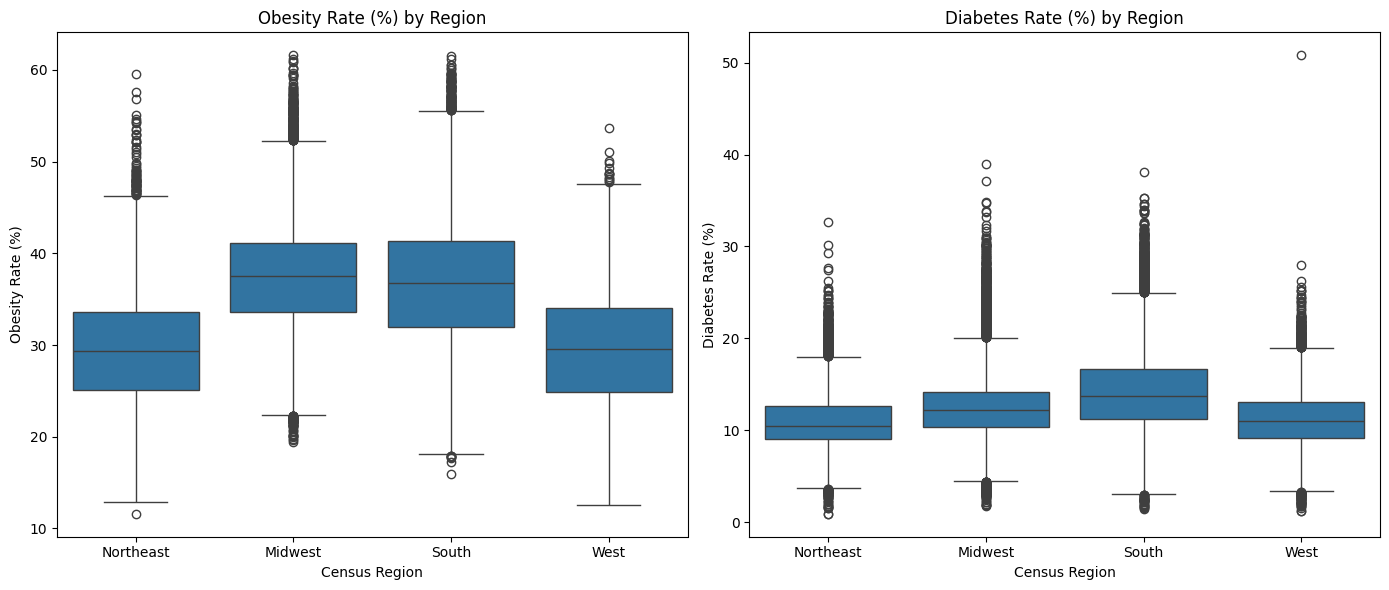

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
region_order = ['Northeast', 'Midwest', 'South', 'West']
region_df = df[df['region'].isin(region_order)]

for ax, (col, label) in zip(axes, [('obesity_pct', 'Obesity Rate (%)'), ('diabetes_pct', 'Diabetes Rate (%)')]):
    sns.boxplot(data=region_df, x='region', y=col, order=region_order, ax=ax)
    ax.set(xlabel='Census Region', ylabel=label, title=label + ' by Region')

plt.tight_layout()
plt.savefig('../data/regional_health_boxplots.png')
plt.show()

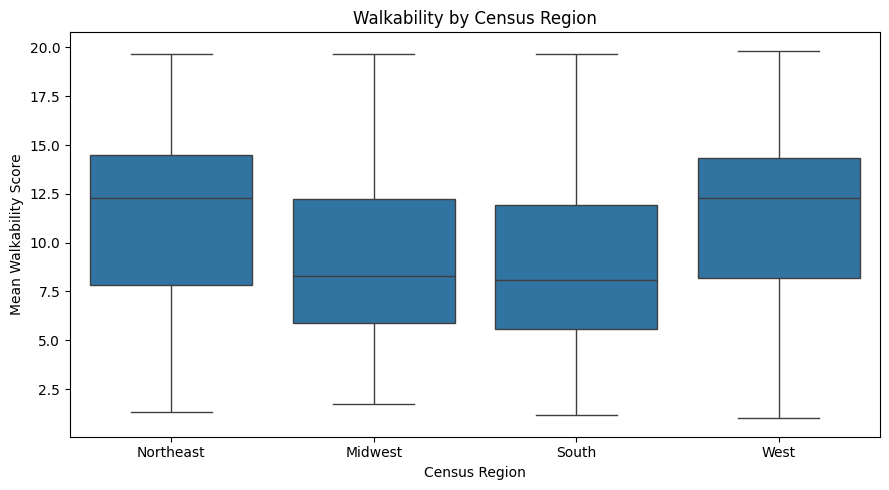

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df[df['region'].isin(region_order)], x='region', y='walkability_mean', order=region_order, ax=ax)
ax.set(xlabel='Census Region', ylabel='Mean Walkability Score', title='Walkability by Census Region')
plt.tight_layout()
plt.savefig('../data/regional_walkability_boxplots.png')
plt.show()

In [ ]:
region_summary = df[df['region'].isin(region_order)].groupby('region')[['walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'LILATracts_1And10']].agg(['mean', 'median']).round(2)
region_summary.columns = ['_'.join(c) for c in region_summary.columns]
region_summary

,walkability_mean_mean,walkability_mean_median,obesity_pct_mean,obesity_pct_median,diabetes_pct_mean,diabetes_pct_median,MHI_mean,MHI_median,LILATracts_1And10_mean,LILATracts_1And10_median
region,,,,,,,,,,
Midwest,8.9900,8.2900,37.4600,37.5000,12.6700,12.2000,75388.1800,70291.0000,0.1300,0.0000
Northeast,11.3100,12.2800,29.4700,29.3000,11.0200,10.5000,97712.2300,89007.0000,0.0500,0.0000
South,8.7100,8.0800,36.7800,36.8000,14.2700,13.7000,74794.0000,64995.5000,0.1800,0.0000
West,11.3200,12.2800,29.6500,29.6000,11.2800,11.0000,95934.5800,86863.0000,0.0900,0.0000


In [ ]:
from scipy import stats

z_cols = ['walkability_mean', 'obesity_pct', 'diabetes_pct']
z = df[z_cols].apply(stats.zscore, nan_policy='omit')
z.columns = [c + '_z' for c in z_cols]
df_z = pd.concat([df, z], axis=1)
outlier_mask = (z.abs() > 3).any(axis=1)
outliers = df_z[outlier_mask].copy()
print(f'{outlier_mask.sum()} outlier tracts')

742 outlier tracts


In [ ]:
cols = ['GEOID_tract', 'state_fips', 'region', 'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI']
display(df_z.nsmallest(10, 'walkability_mean_z')[cols].round(2))
display(df_z.nlargest(10, 'walkability_mean_z')[cols].round(2))

,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI
1124,04005942202,04,West,1.0000,34.1000,19.7000,36736.0000
1143,04007940200,04,West,1.0000,43.4000,21.0000,36523.0000
34220,35053940000,35,West,1.0000,48.8000,24.1000,25245.0000
2006,04017940014,04,West,1.0600,47.5000,26.2000,27198.0000
2002,04017940010,04,West,1.1100,48.1000,24.5000,17377.0000
514,01087232300,01,South,1.1700,49.1000,23.9000,40974.0000
34166,35045943100,35,West,1.1700,40.4000,22.2000,30139.0000
764,01105686800,01,South,1.2500,44.5000,19.7000,45784.0000
1069,04001942600,04,West,1.2500,39.9000,21.5000,28661.0000
29201,28089031000,28,South,1.3300,43.8000,20.0000,39955.0000


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI
44227,41051001102,41,West,19.8300,26.0000,6.0000,106875.0000
3230,06001983200,06,West,19.6700,23.3000,7.8000,181250.0000
5986,06053001300,06,West,19.6700,35.6000,14.5000,61585.0000
10017,08031002000,08,West,19.6700,20.1000,4.8000,106688.0000
12778,12086006203,12,South,19.6700,23.4000,12.2000,97706.0000
16141,17031062500,17,Midwest,19.6700,26.2000,5.4000,169917.0000
37544,36081116700,36,Northeast,19.6700,20.4000,17.4000,55216.0000
6026,06053012302,06,West,19.5000,25.4000,9.3000,114682.0000
7948,06073012302,06,West,19.5000,28.9000,13.9000,44750.0000
8632,06081610202,06,West,19.5000,21.9000,5.1000,179052.0000


In [ ]:
cols = ['GEOID_tract', 'state_fips', 'region', 'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'LILATracts_1And10']
display(df_z.nlargest(10, 'obesity_pct_z')[cols].round(2))
display(df_z.nlargest(10, 'diabetes_pct_z')[cols].round(2))

,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI,LILATracts_1And10
55200,55079008700,55,Midwest,13.3300,61.6000,30.1000,14009.0000,0.0000
14355,13021011500,13,South,9.3300,61.5000,34.6000,12107.0000,0.0000
22212,22073010700,22,South,6.2500,61.2000,32.0000,15536.0000,1.0000
26552,26121004300,26,Midwest,8.8300,61.2000,25.2000,24158.0000,1.0000
18825,17201002600,17,Midwest,8.0800,61.0000,22.4000,15500.0000,0.0000
26524,26121001300,26,Midwest,7.4400,60.9000,24.0000,29434.0000,1.0000
692,01101001200,01,South,14.8300,60.5000,28.0000,20739.0000,0.0000
46493,47113001100,47,South,5.3300,60.5000,29.5000,35798.0000,0.0000
18123,17115000600,17,Midwest,7.3900,60.2000,24.3000,18286.0000,0.0000
21701,22019000200,22,South,6.8300,60.2000,31.3000,22451.0000,1.0000


,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI,LILATracts_1And10
8382,06075980501,06,West,14.3300,14.4000,50.8000,13569.0000,0.0000
40766,39035112100,39,Midwest,12.5800,53.1000,39.0000,11511.0000,0.0000
48454,48141001800,48,South,16.5800,47.7000,38.1000,12899.0000,0.0000
40913,39035152701,39,Midwest,13.6700,52.3000,37.1000,18581.0000,0.0000
600,01097001501,01,South,7.0000,57.8000,35.3000,14399.0000,1.0000
48456,48141002000,48,South,13.5600,46.6000,35.3000,12798.0000,0.0000
40783,39035117201,39,Midwest,12.9400,53.6000,34.8000,16039.0000,0.0000
40759,39035109301,39,Midwest,11.6700,55.9000,34.7000,11036.0000,0.0000
647,01097004800,01,South,6.2500,58.7000,34.6000,9153.0000,0.0000
14355,13021011500,13,South,9.3300,61.5000,34.6000,12107.0000,0.0000


In [ ]:
surprising = df_z[(df_z['walkability_mean_z'] > 1) & (df_z['obesity_pct_z'] > 1.5)].sort_values('obesity_pct', ascending=False)
cols = ['GEOID_tract', 'state_fips', 'region', 'walkability_mean', 'obesity_pct', 'diabetes_pct', 'MHI', 'nhw_pct', 'black_pct', 'hispanic_pct', 'LILATracts_1And10']
display(surprising[cols].head(15).round(2))

,GEOID_tract,state_fips,region,walkability_mean,obesity_pct,diabetes_pct,MHI,nhw_pct,black_pct,hispanic_pct,LILATracts_1And10
692,01101001200,01,South,14.8300,60.5000,28.0000,20739.0000,0.0000,0.9700,0.0100,0.0000
25636,26049003400,26,Midwest,14.4200,59.7000,19.4000,7401.0000,0.1100,0.8600,0.0000,0.0000
705,01101002400,01,South,14.8300,59.6000,31.5000,21607.0000,0.0000,0.9600,0.0000,1.0000
36782,36067004200,36,Northeast,15.9200,59.6000,24.4000,15439.0000,0.0700,0.5900,0.2400,0.0000
55185,55079007000,55,Midwest,14.1200,59.5000,27.2000,20673.0000,0.0700,0.7800,0.0900,0.0000
52851,51760030100,51,South,13.8300,59.0000,27.9000,16732.0000,0.0400,0.9100,0.0000,0.0000
690,01101001000,01,South,14.8300,58.6000,25.3000,32336.0000,0.0900,0.8700,0.0300,1.0000
52748,51710004200,51,South,14.5000,58.5000,32.4000,13566.0000,0.1600,0.7700,0.0700,0.0000
2740,05119002600,05,South,15.0800,58.1000,28.9000,30602.0000,0.1300,0.8700,0.0000,1.0000
18484,17167001600,17,Midwest,14.2100,57.9000,24.9000,22284.0000,0.2300,0.7000,0.0300,0.0000


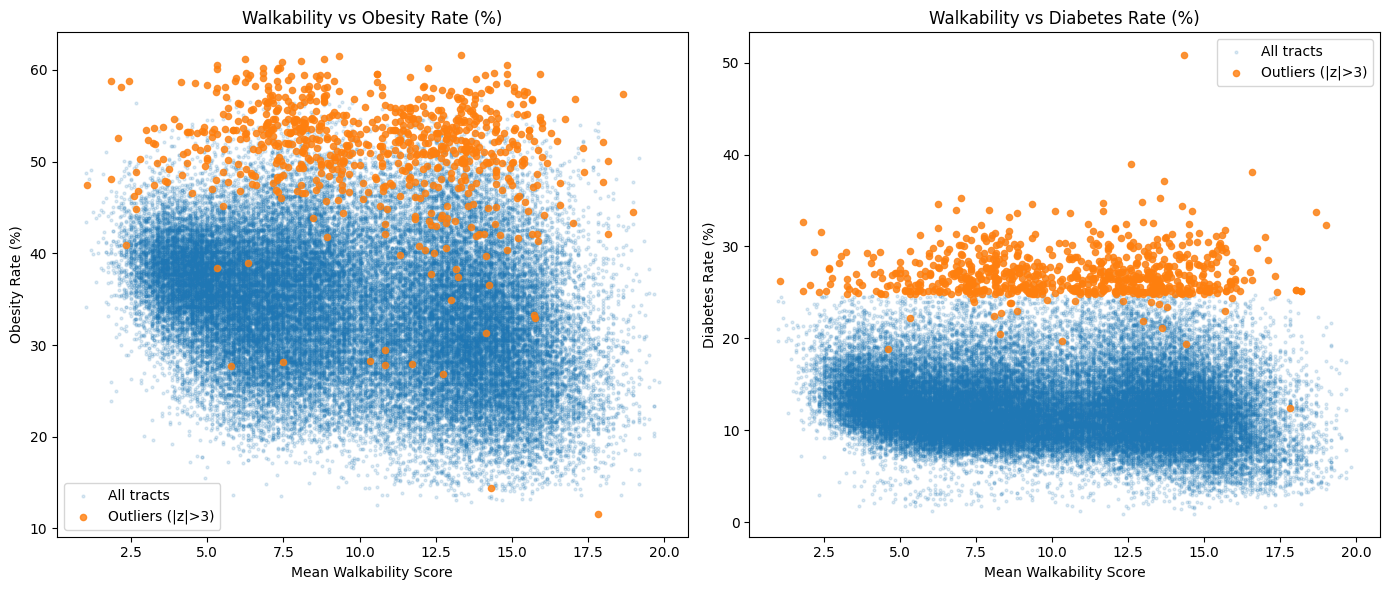

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (y_col, label) in zip(axes, [('obesity_pct', 'Obesity Rate (%)'), ('diabetes_pct', 'Diabetes Rate (%)')]):
    ax.scatter(df_z['walkability_mean'], df_z[y_col], alpha=0.15, s=4, label='All tracts')
    ax.scatter(outliers['walkability_mean'], outliers[y_col], alpha=0.8, s=20, label='Outliers (|z|>3)')
    ax.set(xlabel='Mean Walkability Score', ylabel=label, title=f'Walkability vs {label}')
    ax.legend()
plt.tight_layout()
plt.savefig('../data/outlier_scatter.png')
plt.show()

,food_desert_pct,n_tracts
region,,
South,18.0100,19282
Midwest,13.3700,15137
West,9.4000,13240
Northeast,5.1800,8315


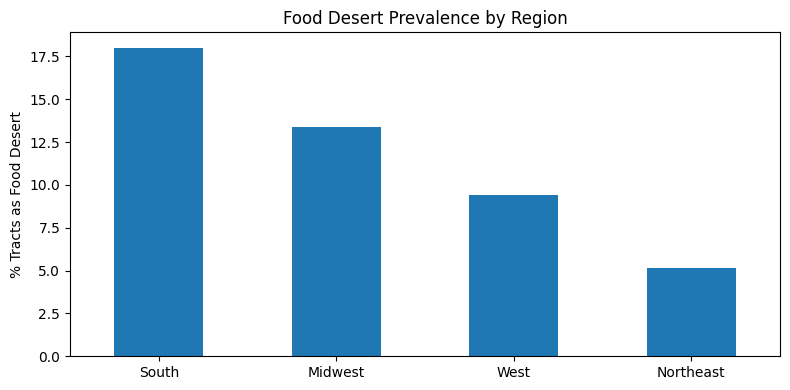

In [ ]:
food_region = df[df['region'].isin(region_order)].groupby('region')['LILATracts_1And10'].agg(food_desert_pct=lambda x: 100 * x.mean(), n_tracts='count').round(2).sort_values('food_desert_pct', ascending=False)
display(food_region)

fig, ax = plt.subplots(figsize=(8, 4))
food_region['food_desert_pct'].plot(kind='bar', ax=ax)
ax.set(ylabel='% Tracts as Food Desert', title='Food Desert Prevalence by Region', xlabel='')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/regional_food_desert.png')
plt.show()

In [ ]:
display(df_z)

,GEOID_tract,walkability_mean,walkability_min,walkability_max,diabetes_pct,obesity_pct,nhw_pct,black_pct,hispanic_pct,no_vehicle_ratio,MHI,state_fips,LILATracts_1And10,LILATracts_halfAnd10,LILATracts_Vehicle,LowIncomeTracts,lapop1share,lalowi1share,lahunv1,lahunv1share,PovertyRate,MedianFamilyIncome,Urban,region,walkability_mean_z,obesity_pct_z,diabetes_pct_z
0,01001020100,4.0833,2.6667,5.5000,13.3000,39.4000,0.7076,0.0897,0.1065,0.0536,62407.0000,01,0.0000,0.0000,0.0000,0.0000,99.1890,24.1108,5.4904,0.7923,11.3365,81250.0000,1.0000,South,-1.4214,0.6929,0.1626
1,01001020200,8.5833,7.6667,9.5000,15.8000,44.7000,0.4175,0.4541,0.0114,0.0647,59028.0000,01,1.0000,1.0000,0.0000,1.0000,58.1102,27.8292,66.9035,9.0045,17.8768,49000.0000,1.0000,South,-0.3007,1.3974,0.7841
2,01001020300,6.8333,4.6667,9.0000,13.9000,40.3000,0.6623,0.2703,0.0108,0.0830,66698.0000,01,0.0000,0.0000,0.0000,0.0000,46.0037,14.1791,0.0000,0.0000,15.0460,62609.0000,1.0000,South,-0.7365,0.8125,0.3117
3,01001020400,7.5417,6.0000,10.0000,12.8000,36.9000,0.8692,0.0616,0.0199,0.0619,75956.0000,01,0.0000,0.0000,0.0000,0.0000,31.0868,7.8253,7.9414,0.4612,2.8452,70607.0000,1.0000,South,-0.5601,0.3606,0.0383
4,01001020600,4.5833,4.5000,4.6667,13.5000,40.7000,0.6815,0.2034,0.0645,0.0228,75375.0000,01,1.0000,1.0000,0.0000,1.0000,93.7177,43.2053,71.7098,5.4699,21.5777,69521.0000,1.0000,South,-1.2968,0.8657,0.2123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55970,56043000200,5.5000,3.6667,6.8333,13.3000,32.7000,0.8933,0.0045,0.0756,0.0225,61293.0000,56,0.0000,0.0000,0.0000,0.0000,81.5997,20.2868,33.7608,2.5635,9.7296,67254.0000,0.0000,West,-1.0686,-0.1977,0.1626
55971,56043000301,10.5556,7.8333,13.3333,13.5000,34.8000,0.7594,0.0000,0.2083,0.0660,61832.0000,56,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,11.5833,64152.0000,1.0000,West,0.1905,0.0814,0.2123
55972,56043000302,7.1667,6.0000,8.3333,15.0000,33.7000,0.7537,0.0000,0.1646,0.0405,65114.0000,56,0.0000,0.0000,0.0000,0.0000,6.1109,1.7192,2.6725,0.2618,16.3290,69605.0000,1.0000,West,-0.6535,-0.0648,0.5852
55973,56045951100,5.1667,5.0000,5.3333,13.6000,37.3000,0.8085,0.0012,0.0307,0.0081,89202.0000,56,0.0000,0.0000,0.0000,0.0000,68.8747,20.7277,13.2164,0.9997,17.4608,74500.0000,0.0000,West,-1.1516,0.4137,0.2371


In [ ]:
import statsmodels.formula.api as smf

ols_diabetes = smf.ols(formula="diabetes_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + MHI + black_pct + hispanic_pct", data=df).fit(cov_type='HC3')
ols_obesity = smf.ols(formula="obesity_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + MHI + black_pct + hispanic_pct", data=df).fit(cov_type='HC3')
print(ols_diabetes.summary())
print(ols_obesity.summary())

                            OLS Regression Results                            
Dep. Variable:           diabetes_pct   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.559
Method:                 Least Squares   F-statistic:                     7333.
Date:                Wed, 29 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:23:57   Log-Likelihood:            -1.3442e+05
No. Observations:               55974   AIC:                         2.689e+05
Df Residuals:                   55967   BIC:                         2.689e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            16.3964      0.04

In [ ]:
food_access_cols = ['lapop1share', 'lalowi1share', 'lahunv1share',
                    'LILATracts_1And10', 'LILATracts_halfAnd10',
                    'LILATracts_Vehicle', 'LowIncomeTracts']
df[food_access_cols] = df[food_access_cols].fillna(0)

before = len(df)
df = df.dropna(subset=['walkability_mean', 'no_vehicle_ratio', 'MHI', 'black_pct', 'hispanic_pct'])
print(f'Dropped {before - len(df)} rows missing true controls, final shape: {df.shape}')

Dropped 0 rows missing true controls, final shape: (55975, 24)


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
features = ["walkability_mean", "lapop1share", "no_vehicle_ratio", "MHI", "black_pct", "hispanic_pct"]
vif_data = pd.DataFrame({'variable': features, 'VIF': [variance_inflation_factor(df[features].values, i) for i in range(len(features))]})
print(vif_data)

           variable    VIF
0  walkability_mean 7.9848
1       lapop1share 1.7749
2  no_vehicle_ratio 2.0577
3               MHI 5.3778
4         black_pct 1.7021
5      hispanic_pct 2.0383


In [ ]:
df.to_csv("../data/merged_data.csv", index=False)
print(f"Saved {len(df)} rows to merged_data.csv")

Saved 55975 rows to merged_data.csv


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# features = ["walkability_mean", "lapop1share", "no_vehicle_ratio", "MHI", "black_pct", "hispanic_pct"]
features = ["walkability_mean", "lapop1share", "no_vehicle_ratio"]
x, y = df[features], df["diabetes_pct"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
ridge.fit(x_train, y_train)
pred = ridge.predict(x_test)
print(f"Train R²: {r2_score(y_train, ridge.predict(x_train)):.4f}, Test R²: {r2_score(y_test, pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.4f}, MAE: {mean_absolute_error(y_test, pred):.4f}")
for name, coef in zip(features, ridge.named_steps['model'].coef_):
    print(f"  {name}: {coef:.4f}")

KeyError: "['lapop1share', 'no_vehicle_ratio'] not in index"

In [ ]:
from sklearn.ensemble import RandomForestRegressor

randomforest = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42))])
randomforest.fit(x_train, y_train)
pred = randomforest.predict(x_test)
print(f"Train R²: {r2_score(y_train, randomforest.predict(x_train)):.3f}, Test R²: {r2_score(y_test, pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f}, MAE: {mean_absolute_error(y_test, pred):.3f}")

Train R²: 0.956, Test R²: 0.682
RMSE: 2.284, MAE: 1.648


In [ ]:
randomforest_adj = Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, max_depth=10, min_samples_leaf=50, max_features=0.5, random_state=42))])
randomforest_adj.fit(x_train, y_train)
pred = randomforest_adj.predict(x_test)
print(f"Train R²: {r2_score(y_train, randomforest_adj.predict(x_train)):.3f}, Test R²: {r2_score(y_test, pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f}, MAE: {mean_absolute_error(y_test, pred):.3f}")

Train R²: 0.711, Test R²: 0.683
RMSE: 2.280, MAE: 1.636


### 11. Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])
gb.fit(x_train, y_train)
pred = gb.predict(x_test)
print(f"Train R²: {r2_score(y_train, gb.predict(x_train)):.3f}, Test R²: {r2_score(y_test, pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.3f}, MAE: {mean_absolute_error(y_test, pred):.3f}")

Train R²: 0.710, Test R²: 0.686
RMSE: 2.268, MAE: 1.629


In [ ]:
importance_df = pd.DataFrame({'feature': features, 'Random Forest': randomforest_adj.named_steps['model'].feature_importances_, 'Gradient Boosting': gb.named_steps['model'].feature_importances_}).sort_values('Random Forest', ascending=False)
print(importance_df)

            feature  Random Forest  Gradient Boosting
3               MHI         0.5902             0.6797
4         black_pct         0.2246             0.1772
5      hispanic_pct         0.0850             0.0721
0  walkability_mean         0.0487             0.0501
2  no_vehicle_ratio         0.0369             0.0124
1       lapop1share         0.0146             0.0085


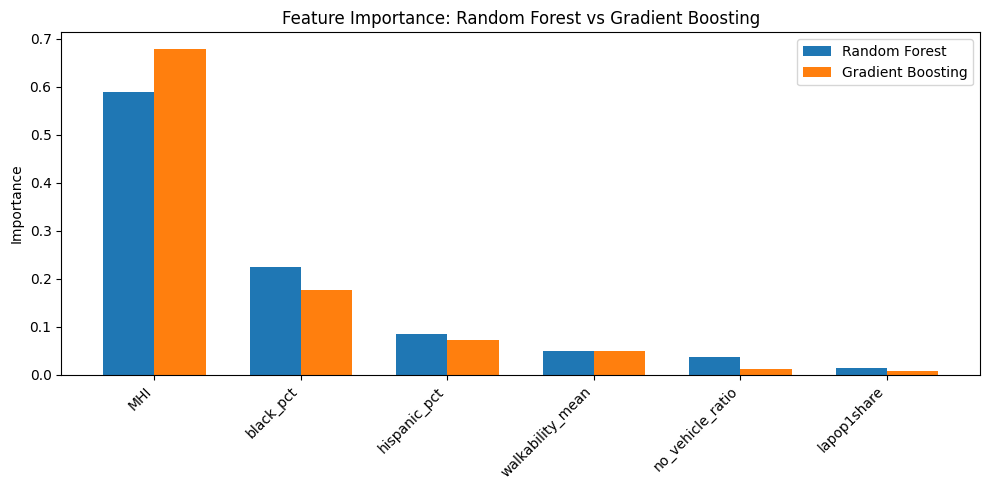

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(features))
width = 0.35
ax.bar(x - width/2, importance_df['Random Forest'], width, label='Random Forest')
ax.bar(x + width/2, importance_df['Gradient Boosting'], width, label='Gradient Boosting')
ax.set_xticks(x)
ax.set_xticklabels(importance_df['feature'], rotation=45, ha='right')
ax.set(ylabel='Importance', title='Feature Importance: Random Forest vs Gradient Boosting')
ax.legend()
plt.tight_layout()
plt.show()

### Model Comparison

In [ ]:
models = {'Ridge': ridge, 'Random Forest': randomforest, 'RF (tuned)': randomforest_adj, 'Gradient Boosting': gb}
rows = []
for name, m in models.items():
    pred = m.predict(x_test)
    rows.append({'Model': name, 'R²': round(r2_score(y_test, pred), 3), 'RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 3), 'MAE': round(mean_absolute_error(y_test, pred), 3)})
pd.DataFrame(rows).set_index('Model')

,R²,RMSE,MAE
Model,,,
Ridge,0.5530,2.7050,1.9820
Random Forest,0.6820,2.2840,1.6480
RF (tuned),0.6830,2.2800,1.6360
Gradient Boosting,0.6860,2.2680,1.6290


In [ ]:
df['county_fips'] = df['GEOID_tract'].str[:5]
formula = "obesity_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + MHI + black_pct + hispanic_pct"
ols_clust = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['county_fips']})
pd.DataFrame({'coef': ols_obesity.params, 'HC3_se': ols_obesity.bse, 'clustered_se': ols_clust.bse, 'HC3_p': ols_obesity.pvalues, 'clustered_p': ols_clust.pvalues}).round(4)

,coef,HC3_se,clustered_se,HC3_p,clustered_p
Intercept,46.2993,0.0710,0.3678,0.0000,0.0000
walkability_mean,-0.5140,0.0057,0.0364,0.0000,0.0000
LILATracts_1And10,1.2576,0.0643,0.1718,0.0000,0.0000
no_vehicle_ratio,-7.5276,0.2217,2.3998,0.0000,0.0017
MHI,-0.0001,0.0000,0.0000,0.0000,0.0000
black_pct,12.4591,0.1156,0.5307,0.0000,0.0000
hispanic_pct,1.8234,0.0992,0.8063,0.0000,0.0238


In [ ]:
formula_int = "obesity_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + MHI + black_pct + hispanic_pct + walkability_mean:LILATracts_1And10 + LILATracts_1And10:no_vehicle_ratio"
ols_int = smf.ols(formula_int, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['county_fips']})
pd.DataFrame({'coef': ols_int.params, 'se': ols_int.bse, 'p': ols_int.pvalues}).round(4)

,coef,se,p
Intercept,46.5507,0.3844,0.0000
walkability_mean,-0.5346,0.0385,0.0000
LILATracts_1And10,-1.8252,0.3143,0.0000
no_vehicle_ratio,-8.1769,2.3104,0.0004
MHI,-0.0001,0.0000,0.0000
black_pct,12.1859,0.5329,0.0000
hispanic_pct,2.0109,0.8139,0.0135
walkability_mean:LILATracts_1And10,0.1848,0.0446,0.0000
LILATracts_1And10:no_vehicle_ratio,15.4783,2.5464,0.0000


In [ ]:
df['income_q'] = pd.qcut(df['MHI'], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
rows = []
for q, sub in df.groupby('income_q', observed=True):
    m = smf.ols("obesity_pct ~ walkability_mean + LILATracts_1And10 + no_vehicle_ratio + black_pct + hispanic_pct", data=sub).fit(cov_type='HC3')
    rows.append({'n': len(sub), 'walk_b': round(m.params['walkability_mean'], 3), 'walk_p': round(m.pvalues['walkability_mean'], 4), 'fd_b': round(m.params['LILATracts_1And10'], 3), 'fd_p': round(m.pvalues['LILATracts_1And10'], 4)})
pd.DataFrame(rows, index=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

,n,walk_b,walk_p,fd_b,fd_p
Q1 (low),13995,-0.3660,0.0000,0.9700,0.0000
Q2,13993,-0.4660,0.0000,0.7950,0.0000
Q3,13993,-0.6040,0.0000,1.1700,0.0000
Q4 (high),13994,-0.5930,0.0000,2.1380,0.0000


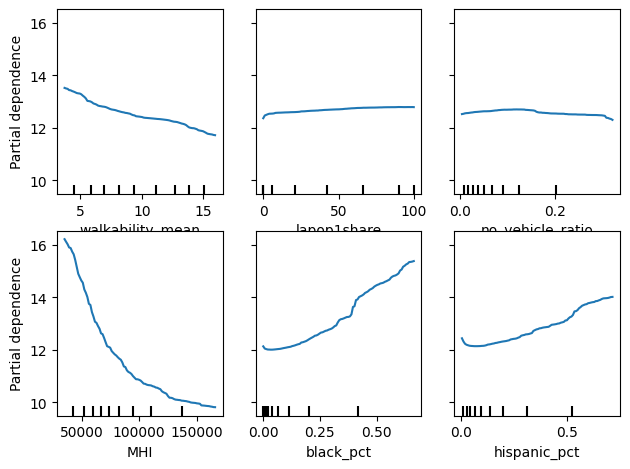

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
PartialDependenceDisplay.from_estimator(randomforest_adj, x_test, features, n_cols=3, random_state=42)
plt.tight_layout()
plt.show()